# 4-3 과제 — **정답 코드**

예시 조합은 `Perimeter + Eccentricity` 임.

> **정답이 하나가 아님.**
> `F1`, `F2` 만 바꾸면 어떤 조합이든 그대로 돌아감.

*데이터: UCI Machine Learning Repository — Raisin (id 850), CC BY 4.0*

## 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 데이터: UCI Machine Learning Repository — Raisin (id=850), CC BY 4.0
try:
    from ucimlrepo import fetch_ucirepo
    df = fetch_ucirepo(id=850).data.original
    print("데이터: UCI 에서 직접 받음")
except Exception as e:
    df = pd.read_csv("raisin.csv")          # 인터넷이 안 되면 옆에 둔 파일
    print("데이터: raisin.csv 에서 읽음 -", type(e).__name__)

# train 576 / validation 144 / test 180
dev, test_df = train_test_split(df, test_size=0.2, stratify=df["Class"], random_state=42)
train_df, valid_df = train_test_split(dev, test_size=0.2, stratify=dev["Class"], random_state=42)
y_train, y_valid, y_test = train_df["Class"], valid_df["Class"], test_df["Class"]

FEATURES = [c for c in df.columns if c != "Class"]


def plot_pair(f1, f2):
    """train 576행으로 두 측정값 산점도를 그림 — 쓰고 싶으면 쓰셈"""
    for label, g in train_df.groupby("Class"):
        plt.scatter(g[f1], g[f2], s=20, alpha=.55, label=label)
    plt.xlabel(f1); plt.ylabel(f2); plt.legend(); plt.grid(alpha=.15)
    plt.title(f"{f1} vs {f2}  (train)")
    plt.show()


print("train", len(train_df), "/ validation", len(valid_df), "/ test", len(test_df))
print("class", dict(df["Class"].value_counts()))
print("features", FEATURES)
print("baseline(찍기)", 0.5)


데이터: raisin.csv 에서 읽음 - ConnectionError
train 576 / validation 144 / test 180
class {'Kecimen': np.int64(450), 'Besni': np.int64(450)}
features ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
baseline(찍기) 0.5


---

## 측정값 7개가 각각 무엇인가

터키에서 재배한 건포도 900알을 **카메라로 찍어서** 이미지 처리로 뽑아낸 값들임.
그래서 넓이·길이 단위가 **픽셀**임.

| 측정값 | 무엇을 재는가 | 대략 범위 |
|---|---|---|
| `Area` | 건포도 안쪽 **픽셀 개수** = 넓이 | 25,000 ~ 235,000 |
| `Perimeter` | 건포도 **둘레** 길이 | 619 ~ 2,698 |
| `MajorAxisLength` | 건포도에 그을 수 있는 **가장 긴 선** | 226 ~ 997 |
| `MinorAxisLength` | 그에 수직인 **가장 짧은 선** | 144 ~ 492 |
| `ConvexArea` | 건포도를 감싸는 **가장 작은 볼록 도형**의 넓이 | 26,000 ~ 278,000 |
| `Eccentricity` | **얼마나 길쭉한가.** 0이면 완전한 원, 1에 가까울수록 납작한 타원 | 0.35 ~ 0.96 |
| `Extent` | 건포도를 감싸는 **사각형 대비 건포도가 차지한 비율.** 얼마나 꽉 찼나 | 0.38 ~ 0.84 |

**`Class`** 가 정답임. `Kecimen` 과 `Besni`, 터키 건포도 두 품종.

---

### 표를 볼 때 짚어둘 것

**범위를 비교해보셈.**

- `Area` 는 **만 단위**임
- `Eccentricity` 와 `Extent` 는 **0에서 1 사이**임

(멈춤)

**만 단위와 소수점을 같이 놓고 "거리"를 재면 무슨 일이 생길까?**

4-2 에서 배운 게 여기서 그대로 쓰임. 문제 3 에서 확인하게 됨.

---

### 비슷해 보이는 것끼리

- `Area` 와 `ConvexArea` — 둘 다 **넓이**임. 값도 비슷하게 움직임
- `MajorAxisLength` 와 `MinorAxisLength` — 둘 다 **길이**
- `Eccentricity` 와 `Extent` — 둘 다 **모양 비율**. 크기와 무관함

> **비슷한 둘을 같이 고르면 정보가 하나뿐일 수도 있음.**
> 서로 다른 성격을 섞는 게 나을지, 같은 성격끼리가 나을지 — 직접 골라보셈.

*출처: UCI Machine Learning Repository — Raisin (id 850)*
*Selçuk University 에서 CVS(Computer Vision System) 로 촬영·추출. CC BY 4.0*

---

## 측정값 7개가 각각 무엇인가

터키에서 재배한 건포도 900알을 **카메라로 찍어서** 이미지 처리로 뽑아낸 값들임.
그래서 넓이·길이 단위가 **픽셀**임.

| 측정값 | 무엇을 재는가 | 대략 범위 |
|---|---|---|
| `Area` | 건포도 안쪽 **픽셀 개수** = 넓이 | 25,000 ~ 235,000 |
| `Perimeter` | 건포도 **둘레** 길이 | 619 ~ 2,698 |
| `MajorAxisLength` | 건포도에 그을 수 있는 **가장 긴 선** | 226 ~ 997 |
| `MinorAxisLength` | 그에 수직인 **가장 짧은 선** | 144 ~ 492 |
| `ConvexArea` | 건포도를 감싸는 **가장 작은 볼록 도형**의 넓이 | 26,000 ~ 278,000 |
| `Eccentricity` | **얼마나 길쭉한가.** 0이면 완전한 원, 1에 가까울수록 납작한 타원 | 0.35 ~ 0.96 |
| `Extent` | 건포도를 감싸는 **사각형 대비 건포도가 차지한 비율.** 얼마나 꽉 찼나 | 0.38 ~ 0.84 |

**`Class`** 가 정답임. `Kecimen` 과 `Besni`, 터키 건포도 두 품종.

---

### 표를 볼 때 짚어둘 것

**범위를 비교해보셈.**

- `Area` 는 **만 단위**임
- `Eccentricity` 와 `Extent` 는 **0에서 1 사이**임

(멈춤)

**만 단위와 소수점을 같이 놓고 "거리"를 재면 무슨 일이 생길까?**

4-2 에서 배운 게 여기서 그대로 쓰임. 문제 3 에서 확인하게 됨.

---

### 비슷해 보이는 것끼리

- `Area` 와 `ConvexArea` — 둘 다 **넓이**임. 값도 비슷하게 움직임
- `MajorAxisLength` 와 `MinorAxisLength` — 둘 다 **길이**
- `Eccentricity` 와 `Extent` — 둘 다 **모양 비율**. 크기와 무관함

> **비슷한 둘을 같이 고르면 정보가 하나뿐일 수도 있음.**
> 서로 다른 성격을 섞는 게 나을지, 같은 성격끼리가 나을지 — 직접 골라보셈.

*출처: UCI Machine Learning Repository — Raisin (id 850)*
*Selçuk University 에서 CVS(Computer Vision System) 로 촬영·추출. CC BY 4.0*

## 문제 1 — 측정값 2개 고르기

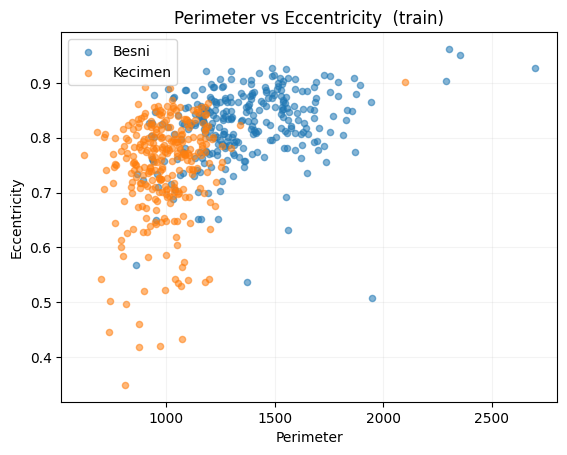

Perimeter + Eccentricity  train CV = 0.8454


In [2]:
F1, F2 = "Perimeter", "Eccentricity"
X_train, X_valid = train_df[[F1, F2]], valid_df[[F1, F2]]

plot_pair(F1, F2)
pair_cv = cross_val_score(
    Pipeline([("s", StandardScaler()), ("k", KNeighborsClassifier(5))]),
    X_train, y_train, cv=5).mean()
print(f"{F1} + {F2}  train CV = {pair_cv:.4f}")

## 문제 2 — 로지스틱 회귀 vs KNN

In [3]:
lr = LogisticRegression(max_iter=5000).fit(X_train, y_train)
lr_pred = lr.predict(X_valid)
lr_acc = accuracy_score(y_valid, lr_pred)

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
knn_pred = knn.predict(X_valid)
knn_acc = accuracy_score(y_valid, knn_pred)

print(f"LR         {lr_acc:.4f}   (기준선 대비 {lr_acc-0.5:+.4f})")
print(f"KNN k=5    {knn_acc:.4f}   (기준선 대비 {knn_acc-0.5:+.4f})")

LR         0.8750   (기준선 대비 +0.3750)
KNN k=5    0.8611   (기준선 대비 +0.3611)


## 문제 3 — 스케일링

In [4]:
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)     # train 에는 fit_transform
X_valid_s = sc.transform(X_valid)         # validation 에는 transform

knn_s = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
pred_s = knn_s.predict(X_valid_s)
scaled_acc = accuracy_score(y_valid, pred_s)
changed = int((knn_pred != pred_s).sum())

print(f"스케일링 전  {knn_acc:.4f}")
print(f"스케일링 후  {scaled_acc:.4f}")
print(f"예측이 바뀐 건포도  {changed} / {len(y_valid)}")

스케일링 전  0.8611
스케일링 후  0.8681
예측이 바뀐 건포도  19 / 144


## 문제 4 — k 고르기

In [5]:
K_LIST = [3, 5, 7, 9, 11, 15]
pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
grid = GridSearchCV(pipe, {"knn__n_neighbors": K_LIST}, cv=5).fit(X_train, y_train)

best_k = grid.best_params_["knn__n_neighbors"]
tuned_acc = accuracy_score(y_valid, grid.predict(X_valid))

print(f"후보        {K_LIST}")
print(f"고른 k      {best_k}   (train CV {grid.best_score_:.4f})")
print(f"validation  {tuned_acc:.4f}   (k=5 였을 때 {scaled_acc:.4f})")

후보        [3, 5, 7, 9, 11, 15]
고른 k      15   (train CV 0.8594)
validation  0.8681   (k=5 였을 때 0.8681)


## 문제 5 — 최종 모델 하나 고르기

In [6]:
board = pd.DataFrame({
    "모델": ["로지스틱 회귀", "KNN k=5 raw", "KNN k=5 scaled", f"KNN k={best_k} tuned"],
    "validation": [lr_acc, knn_acc, scaled_acc, tuned_acc],
})
print(board.round(4).to_string(index=False))

            모델  validation
       로지스틱 회귀      0.8750
   KNN k=5 raw      0.8611
KNN k=5 scaled      0.8681
KNN k=15 tuned      0.8681


## 문제 6 — test 딱 한 번

In [7]:
X_dev, X_test = dev[[F1, F2]], test_df[[F1, F2]]
final_model = LogisticRegression(max_iter=5000).fit(X_dev, dev["Class"])
test_acc = accuracy_score(y_test, final_model.predict(X_test))

print(f"validation  {lr_acc:.4f}")
print(f"final test  {test_acc:.4f}   (n={len(y_test)})")
print(f"1명 틀릴 때 움직이는 폭  {1/len(y_test):.4f}")

validation  0.8750
final test  0.8611   (n=180)
1명 틀릴 때 움직이는 폭  0.0056


---

## 서술 예시 답안

**서술 1 — 고른 이유**
> 산점도에서 `Perimeter` 축을 따라 두 품종의 중심이 눈에 띄게 달랐고,
> `Eccentricity` 를 같이 보니 겹치는 띠가 가운데로 좁아져서 골랐음.

**서술 2 — 스케일링 전후**
> 정확도는 0.8611 에서 0.8681 로 0.007 올랐음.
> 그런데 validation 144개 중 **19개, 약 13%** 의 예측이 바뀌었음.
> 점수 변화는 작지만 모델의 판단 자체는 꽤 달라졌다고 봄.

**서술 3 — 최종 선택**
> 최종 선택: 로지스틱 회귀
> 근거 1 — validation 0.8750 으로 네 모델 중 가장 높았고, 기준선 0.5 대비 **+0.375** 임.
> 근거 2 — 계수를 꺼내 볼 수 있어서 왜 그렇게 판단했는지 설명할 수 있음.
> KNN 은 점수가 비슷해도 근거를 못 대므로 로지스틱을 택함.

**서술 4 — validation vs test**
> validation 0.8750, test 0.8611 로 **0.0139** 낮았음.
> test 가 180개이므로 이는 약 **2~3명** 차이임.
> validation 을 보고 모델을 골랐기 때문에 validation 이 유리하게 나온 것으로 봄.

**서술 5 — 한계**
> 측정값을 2개만 썼음. 나머지 5개는 보지 않았음.
> test 도 180개뿐이라 한 명이 0.0056 을 움직임.

**서술 6 — 다음에 확인할 것**
> 다른 조합 5개를 더 돌려서 이번 조합이 좋은 편인지 비교해보고 싶음.
> `random_state` 를 바꿔서 결과가 얼마나 흔들리는지도 확인하고 싶음.